# Section 3 &middot; The Signal (Connors RSI-2)

*The Honest Edge.*

So far machine learning has struck out: it cannot call tomorrow's direction
(Section 1), and a generic ML strategy was just a worse buy-and-hold (Section 2).
So we change tack. We **stop asking a model to predict** and instead bring a real,
named, decades-old rule that people actually trade, then run it through the exact
honest harness we just built.

The rule is **Connors RSI-2**. Does a famous strategy survive contact with honest
validation, costs, and buy-and-hold SPY? This is where the course earns its title.

## What the rule says

Connors RSI-2 is a **mean-reversion** rule (Connors & Alvarez, 2008). The bet:
after a sharp short-term drop *within an uptrend*, price tends to snap back.

**Analogy: a stretched rubber band.** Pull it hard and it springs back. The rule
tries to buy the band at full stretch and sell as it snaps back.

Four ingredients, nothing more:

| ingredient | rule | plain English |
|---|---|---|
| **trend filter** | `close > 200-day average` | only buy dips in an uptrend |
| **oversold trigger** | `RSI(2) < 10` | price is sharply oversold *right now* |
| **exit** | `close > 5-day average` | the bounce arrived, take it |
| **stop** | none | Connors found stops *hurt* mean-reversion |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from honest_edge import data, indicators as ind, signal, evaluation as ev

spy = data.load_spy_daily()
close = spy["close"]
print("SPY daily:", spy.shape, " range:", spy.index.min().date(), "->", spy.index.max().date())

SPY daily: (5000, 6)  range: 2006-05-05 -> 2026-03-20


## The oversold meter: RSI(2)

RSI runs 0 to 100. High means recent moves were mostly up (overbought); low means
mostly down (oversold). The number in brackets is the lookback. Connors uses **2**,
which is almost no smoothing, so RSI(2) is a **hair-trigger**: it slams toward 0
after just two or three down days. That twitchiness is the point, it catches sharp,
short dips that a slow RSI(14) would miss. It is the very same `rsi()` from Section
1, called with length 2.

In [2]:
rsi2 = ind.rsi(close, 2)
print(f"RSI(2) range: {rsi2.min():.1f} to {rsi2.max():.1f}")
print(f"share of days below 10: {(rsi2 < 10).mean():.1%}")
print(f"share of days below  5: {(rsi2 <  5).mean():.1%}")
# Look-ahead check: rsi/sma use only past+present bars, so a value at day t never
# sees day t+1. The only future step is execution, which the backtest lags by a bar.

RSI(2) range: 0.1 to 100.0
share of days below 10: 10.0%
share of days below  5: 5.0%


## The trend filter: never catch a falling knife

The single most important ingredient is the **200-day filter**: only buy when
price is above its 200-day average. Oversold in an uptrend is a dip to buy;
oversold in a downtrend is a knife to avoid. **Analogy:** catch a ball bouncing
down the stairs, not one falling off the roof.

Watch this filter closely. It is also what quietly stands in for a stop-loss: by
keeping us out during bear markets, it is what lets a no-stop strategy survive 2008.
(That is not a general license to trade without risk limits. It works here only
because the rule is tightly trend-filtered and in the market a tenth of the time.)

In [3]:
entry, exit_ = signal.connors_rsi2_signals(spy, rsi_buy=10)   # bars where uptrend AND oversold both hold
n_bars = int(entry.sum())
n_dips = int((entry & ~entry.shift(1, fill_value=False)).sum())   # first bar of each oversold run
print(f"bars meeting the entry condition: {n_bars}")
print(f"distinct dips (a run of oversold bars counts once): {n_dips}")
print("The condition can stay true for two or three bars inside one dip, so the raw")
print("count overstates the trades. The position state machine in the next cell")
print("collapses each run into a single trade (you will see ~150 round-trips).")

bars meeting the entry condition: 280
distinct dips (a run of oversold bars counts once): 168
The condition can stay true for two or three bars inside one dip, so the raw
count overstates the trades. The position state machine in the next cell
collapses each run into a single trade (you will see ~150 round-trips).


## From rules to positions

Entry and exit are events; a backtest needs a **position** on every bar (long or
flat). We walk the bars with a tiny state machine: when flat, an entry signal
opens a long; while long, we stay in until an exit signal. We hold at least one
bar, which avoids flip-flopping if entry and exit land on the same day.

The position is what we *held* as of each close. The harness adds the one-bar
execution lag (the position chosen at today's close is held over the next bar's
return), so we never shift it ourselves, doing so would lag the trade twice. If an
entry and exit signal ever land on the same bar, we simply enter and hold at least
one bar.

In [4]:
positions = signal.connors_rsi2(spy, rsi_buy=10)

# In-trade hit-rate: of the bars we were actually long, how often was the next bar up?
# (The harness hit_rate is bar-level and cost-adjusted; here we want the clean
# next-bar up-rate on the bars we held, so we compute that one by hand.)
next_ret = close.pct_change().shift(-1)
held = positions == 1
print(f"time in the market: {held.mean():.1%}  (flat the other ~90%)")
print(f"round-trip trades:  {int((positions.diff() > 0).sum())}")
print(f"in-trade hit-rate:  {(next_ret[held] > 0).mean():.1%}  (above a coin flip, unlike Sections 1-2)")

time in the market: 10.5%  (flat the other ~90%)
round-trip trades:  150
in-trade hit-rate:  56.6%  (above a coin flip, unlike Sections 1-2)


## What the signal actually sees

A picture makes the rule click. Below is one stretch (2018-2019, which had two
sharp selloffs): SPY with its 200-day and 5-day averages on top, green markers
where the rule buys, and RSI(2) underneath with the 10 and 5 lines. Every green
marker sits on an RSI(2) dip *while price is above the 200-day line*.

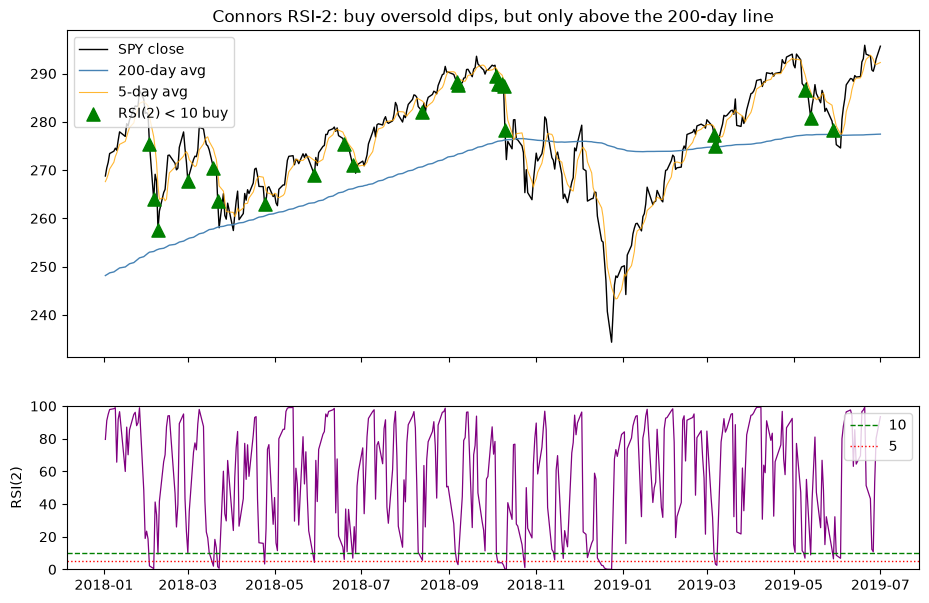

In [5]:
win = slice("2018-01-01", "2019-07-01")
c = close.loc[win]
sma200 = ind.sma(close, 200).loc[win]
sma5 = ind.sma(close, 5).loc[win]
buys = c.index[entry.loc[win]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[2, 1])
ax1.plot(c.index, c, color="black", lw=1, label="SPY close")
ax1.plot(sma200.index, sma200, color="steelblue", lw=1, label="200-day avg")
ax1.plot(sma5.index, sma5, color="orange", lw=0.8, alpha=0.8, label="5-day avg")
ax1.scatter(buys, c.loc[buys], marker="^", color="green", s=90, zorder=3, label="RSI(2) < 10 buy")
ax1.set_title("Connors RSI-2: buy oversold dips, but only above the 200-day line")
ax1.legend(loc="upper left")

ax2.plot(rsi2.loc[win].index, rsi2.loc[win], color="purple", lw=0.9)
ax2.axhline(10, color="green", ls="--", lw=1, label="10")
ax2.axhline(5, color="red", ls=":", lw=1, label="5")
ax2.set_ylabel("RSI(2)"); ax2.set_ylim(0, 100); ax2.legend(loc="upper right")
plt.show()

## The only test that matters: trade it honestly

The signal looks sensible. But "sensible" is not "profitable." We trade it through
the harness, pay a conservative 2 bps per trade, and compare to the two baselines
that count: **buy-and-hold SPY** (beat this or you have nothing) and a **random**
long/flat trader.

In [6]:
# ev.summary_row is the shared four-number projection (Sharpe, Sortino, max DD,
# total return), defined once in the library so every section renders metrics alike.
strat = ev.backtest_positions(positions, close, cost_bps=2.0)
bh = ev.buy_and_hold(close)

# Average the random baseline over 30 coin-flip runs, so one lucky seed can't
# flatter or flatter it. (A single random run swings a lot.)
rnd_runs = [ev.perf_metrics(ev.backtest_positions(
    ev.random_positions(positions.index, seed=s), close, cost_bps=2.0)) for s in range(30)]
rnd_row = {k: np.mean([m[v] for m in rnd_runs]) for k, v in
           {"Sharpe": "sharpe", "Sortino": "sortino",
            "max DD": "max_drawdown", "total return": "total_return"}.items()}
rnd = ev.backtest_positions(ev.random_positions(positions.index, seed=0), close, cost_bps=2.0)  # one run, for the curve

pd.DataFrame({"Connors RSI-2 (2 bps)": ev.summary_row(strat),
              "Buy & Hold SPY": ev.summary_row(bh),
              "Random, avg of 30 (2 bps)": rnd_row}).T.style.format(
    {"Sharpe": "{:.2f}", "Sortino": "{:.2f}", "max DD": "{:.1%}", "total return": "{:.0%}"})

,Sharpe,Sortino,max DD,total return
Connors RSI-2 (2 bps),0.50,0.71,-14.8%,80%
Buy & Hold SPY,0.51,0.71,-56.5%,389%
"Random, avg of 30 (2 bps)",0.24,0.34,-43.8%,72%


## Read it honestly

This is the most interesting table in the course so far. The strategy's **Sharpe
essentially ties buy-and-hold** (around 0.50 vs 0.51), and its **max drawdown is
roughly four times smaller** (about -15% vs -56%), all while sitting in the market
**only ~10% of the time**. It earns a buy-and-hold-like risk-adjusted return on a
fraction of the exposure, and it sidesteps the 2008 cliff.

But be honest about the catch: its **total return is far lower** (it is flat 90% of
the time, so it misses most of the bull market), and on a pure Sharpe basis it does
**not clearly beat** buy-and-hold. This is a real, respectable rule, not free money.

A word on the random baseline: a coin-flip trader is long about half the time, so
in a 20-year bull market it inherits roughly *half* of buy-and-hold's Sharpe for
free. That makes it a surprisingly stiff bar on risk-adjusted terms (which is why
we average 30 runs rather than trust one). The strategy's genuine win over random
is not Sharpe, it is the **much smaller drawdown** and the tiny time in the market.

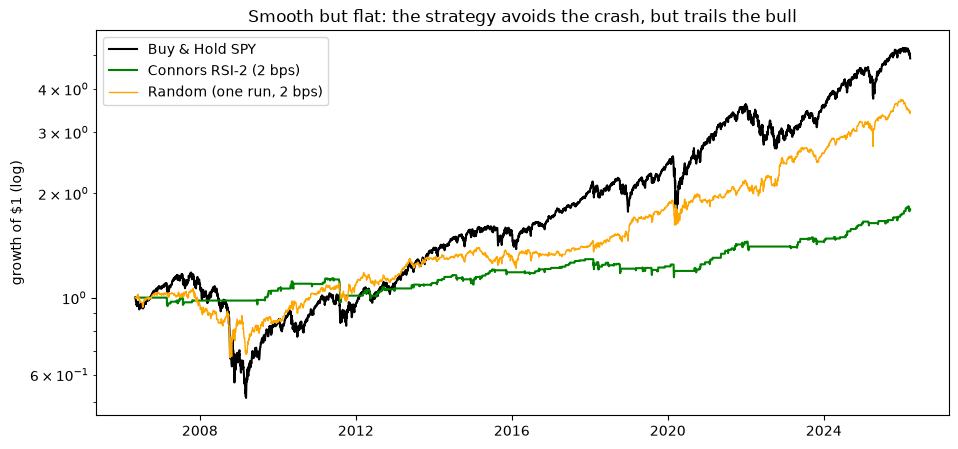

In [7]:
eq = ev.equity_curve   # growth of $1, from the library

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq(bh).index, eq(bh), color="black", lw=1.5, label="Buy & Hold SPY")
ax.plot(eq(strat).index, eq(strat), color="green", lw=1.5, label="Connors RSI-2 (2 bps)")
ax.plot(eq(rnd).index, eq(rnd), color="orange", lw=1, label="Random (one run, 2 bps)")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)")
ax.set_title("Smooth but flat: the strategy avoids the crash, but trails the bull")
ax.legend()
plt.show()

## Do costs hurt? Barely.

Unlike Section 2's churning model, this rule trades only ~150 times in 20 years,
so costs nibble rather than destroy. Watch the Sharpe degrade gently as we crank
the cost from 0 to 5 bps.

In [8]:
rows = {}
for bps in [0, 2, 5]:
    m = ev.perf_metrics(ev.backtest_positions(positions, close, cost_bps=bps))
    rows[f"{bps} bps"] = {"Sharpe": m["sharpe"], "total return": m["total_return"]}
pd.DataFrame(rows).T.style.format({"Sharpe": "{:.2f}", "total return": "{:.0%}"})

,Sharpe,total return
0 bps,0.55,91%
2 bps,0.50,80%
5 bps,0.43,64%


## Is "more selective" better? (testing Connors' claim)

Connors reported that buying deeper dips, RSI(2) below **5** instead of 10, gave
*higher* returns. A good habit: never take such claims on faith. Let's just test it.

In [9]:
pos5 = signal.connors_rsi2(spy, rsi_buy=5)
strat5 = ev.backtest_positions(pos5, close, cost_bps=2.0)
pd.DataFrame({"RSI(2) < 10": ev.summary_row(strat),
              "RSI(2) < 5":  ev.summary_row(strat5)}).T.style.format(
    {"Sharpe": "{:.2f}", "Sortino": "{:.2f}", "max DD": "{:.1%}", "total return": "{:.0%}"})

,Sharpe,Sortino,max DD,total return
RSI(2) < 10,0.50,0.71,-14.8%,80%
RSI(2) < 5,0.46,0.66,-14.1%,55%


In [10]:
# On our SPY data the deeper-dip version is NOT clearly better: fewer trades, similar
# or slightly lower Sharpe. Published edges often wash out out-of-sample.
#
# Where does the edge live? Split cleanly at 2010, around the 2008-09 crash.
for lo, hi, label in [(None, "2009", "through 2009"), ("2010", None, "2010 onward")]:
    s = ev.perf_metrics(strat.loc[lo:hi])["sharpe"]
    b = ev.perf_metrics(bh.loc[lo:hi])["sharpe"]
    print(f"{label:13s} strategy Sharpe {s:+.2f}   buy & hold Sharpe {b:+.2f}")
print("\nThe edge lives in stress: through the 2008-09 crash the strategy stayed")
print("positive while buy-and-hold bled. In the long bull since, buy-and-hold pulls")
print("ahead because the strategy is flat most of the time. The rule did not decay;")
print("it is simply a crash-avoider, not a compounding machine.")

through 2009  strategy Sharpe +0.29   buy & hold Sharpe -0.04
2010 onward   strategy Sharpe +0.54   buy & hold Sharpe +0.72

The edge lives in stress: through the 2008-09 crash the strategy stayed
positive while buy-and-hold bled. In the long bull since, buy-and-hold pulls
ahead because the strategy is flat most of the time. The rule did not decay;
it is simply a crash-avoider, not a compounding machine.


## The honest verdict, and the pivot

A real, named rule **roughly keeps up with buy-and-hold on risk-adjusted terms,
with a quarter of the drawdown and a tenth of the exposure**, but it does **not
clearly beat** buy-and-hold after costs. Why not? Because it takes **every** oversold
dip, the good and the bad, blindly.

That last sentence is the hinge of the entire course. The raw rule is a decent
*candidate generator*: it raises its hand on genuinely oversold days. What it lacks
is judgment about **which** of those dips are worth taking.

That is exactly the job of **meta-labeling**, and it is where machine learning
finally earns its place, not predicting the market, but *filtering a signal we
already trust*:

- **Section 4** labels every RSI-2 trade as a win or loss the right way (the
  triple-barrier method).
- **Sections 5-6** train a model to look at each dip and decide: take it, or skip it.

The primary signal stays. ML becomes the manager who decides which of its trades
to actually fund.